In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\users\kcs\anaconda3\lib\site-packages (2.2.2)



In [3]:
import pandas as pd
df = pd.read_csv("E:\Healthcare_cost_analysis\data\insurance.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\H'
<>:2: SyntaxWarning: invalid escape sequence '\H'
C:\Users\KCS\AppData\Local\Temp\ipykernel_8016\185604507.py:2: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\Healthcare_cost_analysis\data\insurance.csv")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [7]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


1

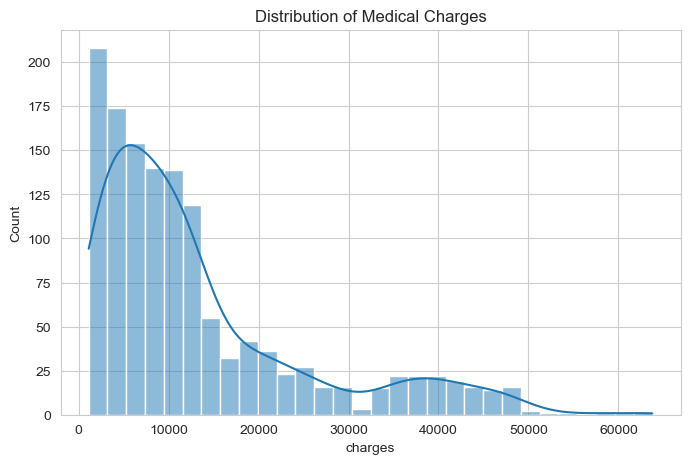

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde = True)
plt.title('Distribution of Medical Charges')
plt.show()

# Distribution of Medical Charges
The distribution of medical insurance charges is positively skewed.Most individuals incur relatively lower medical costs, while a small proportion of individuals exhibit extremely high healthcare expenses.This suggests the presence of high-risk or high-cost patient segments, which may significantly influence overall healthcare expenditure.


In [13]:
df.drop_duplicates()
df.shape

(1338, 7)

In [15]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

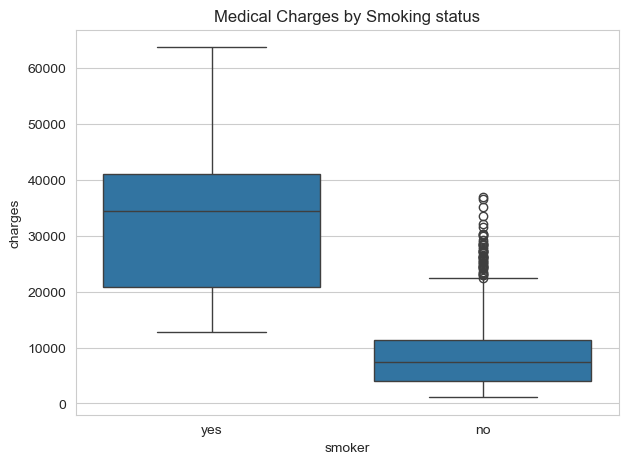

In [17]:
plt.figure(figsize = (7, 5))
sns.boxplot(x = 'smoker', y = 'charges', data = df)
plt.title('Medical Charges by Smoking status')
plt.show()


# Impact of Smoking on Medical Charges
The analysis reveals a substantial difference in healthcare expenditure between smokers and non-smokers.
• Average charge for smokers: ₹32,050
• Average charge for non-smokers: ₹8,434
Smokers incur nearly four times higher medical expenses compared to non-smokers.The boxplot further confirms this disparity, showing a significantly higher median and wider distribution of charges among smokers. This suggests that smoking status is a critical determinant of healthcare cost. From a healthcare management perspective, smoking cessation programs could play a vital role in reducing overall medical expenditure.


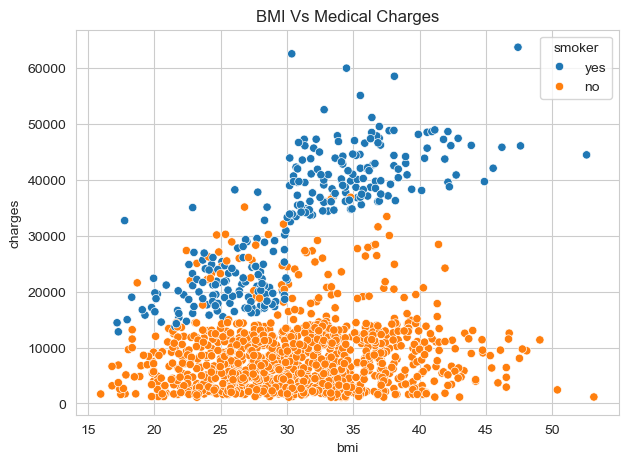

In [21]:
plt.figure(figsize = (7, 5))
sns.scatterplot(x = 'bmi', y = 'charges', hue = 'smoker', data = df)
plt.title('BMI Vs Medical Charges')
plt.show()

# BMI and Age Impact on Medical Charges
The correlation analysis reveals:
• Age shows a moderate positive correlation with medical charges (r = 0.29), indicating that healthcare expenses tend to increase with age.
• BMI demonstrates a weaker positive correlation (r = 0.19), suggesting that higher BMI is associated with increased medical costs, though not strongly in isolation.
• Number of children has negligible correlation with medical expenses (r = 0.06).
However, the scatter plot reveals a critical interaction effect:
- Smokers with higher BMI incur significantly higher medical costs compared to non-smokers with similar BMI levels.
- This indicates that smoking amplifies the financial impact of obesity on healthcare expenditure.


In [25]:
df[['age', 'charges', 'children', 'bmi']].corr()

,age,charges,children,bmi
age,1.000000,0.299008,0.042469,0.109272
charges,0.299008,1.000000,0.067998,0.198341
children,0.042469,0.067998,1.000000,0.012759
bmi,0.109272,0.198341,0.012759,1.000000


In [27]:
df['high_cost'] = df['charges'] > df['charges'].median()
df.groupby('smoker')['high_cost'].mean()

smoker
no     0.371241
yes    1.000000
Name: high_cost, dtype: float64

# High-Cost Patient Segmentation
Patients were categorized as "high-cost" if their medical charges exceeded the median value.
Results show:
• 100% of smokers fall into the high-cost category.
• Only 37% of non-smokers fall into the high-cost category.
This indicates that smoking status is the most dominant predictor of high medical expenditure in the dataset. From a healthcare management perspective, targeted smoking cessation initiatives could significantly reduce high-cost patient burden.


In [31]:
df.groupby('region')['charges'].mean()

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [33]:
df['age_group'] = pd.cut(df['age'],
                         bins=[18,30,45,60,100],
                         labels=['young','adult','middle_aged','senior'])
df['bmi_category'] = pd.cut(df['bmi'],
                           bins=[0,18.5,25,30,100],
                           labels=['underweight','normal','overweight','obese'])
df.groupby(['age_group','smoker'])['charges'].mean()


C:\Users\KCS\AppData\Local\Temp\ipykernel_8016\779066820.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group','smoker'])['charges'].mean()


age_group    smoker
young        no         4705.758286
             yes       27825.092529
adult        no         7246.170138
             yes       31707.164316
middle_aged  no        12188.334036
             yes       36451.732069
senior       no        15366.613482
             yes       38929.615407
Name: charges, dtype: float64

# Age and Smoking Interaction
Medical expenses increase progressively with age. However, smoking significantly amplifies healthcare costs across all age groups. Senior smokers exhibit the highest average charges (~₹38,930), making them the most financially high-risk segment.
This indicates that aging combined with smoking behavior substantially increases healthcare burden.


In [37]:
df.groupby(['bmi_category','smoker'])['charges'].mean()

C:\Users\KCS\AppData\Local\Temp\ipykernel_8016\3268257181.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['bmi_category','smoker'])['charges'].mean()


bmi_category  smoker
underweight   no         5485.056800
              yes       18809.824980
normal        no         7734.650116
              yes       19942.223641
overweight    no         8226.088675
              yes       22491.182935
obese         no         8853.277294
              yes       41692.808992
Name: charges, dtype: float64

# BMI and Smoking Interaction
##While BMI alone shows a moderate impact on medical expenses, its effect becomes significantly amplified when combined with smoking.
##Obese smokers incur the highest average medical charges (~₹41,693), making them the most financially high-risk segment.
##This suggests that the combined presence of lifestyle risk factors substantially increases healthcare costs.
##From a public health standpoint, integrated obesity and smoking intervention programs could significantly reduce healthcare expenditure.


In [41]:
df_model = df.copy()

df_model=pd.get_dummies(df_model, drop_first=True)
df_model.head()

,age,bmi,children,charges,high_cost,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_group_adult,age_group_middle_aged,age_group_senior,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,27.900,0,16884.92400,True,False,True,False,False,True,False,False,False,False,True,False
1,18,33.770,1,1725.55230,False,True,False,False,True,False,False,False,False,False,False,True
2,28,33.000,3,4449.46200,False,True,False,False,True,False,False,False,False,False,False,True
3,33,22.705,0,21984.47061,True,True,False,True,False,False,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,False,True,False,False,True,False,False,False,True,False


In [43]:
X = df_model.drop('charges',axis=1)
y = df_model['charges']

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error
y_pred = model.predict(X_test)
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

R2 score: 0.8103428861024062
MAE: 4107.905207308596


# Model Performance
The linear regression model achieved an R² score of 0.81, indicating that the model explains approximately 81% of the variability in medical charges. The Mean Absolute Error (MAE) is approximately 4108, meaning the model's predictions differ from actual medical charges by around $4100 on average. This level of performance suggests that demographic and behavioral variables such as age, BMI, and smoking status are strong predictors of healthcare expenditure


In [53]:
coefficients = pd.DataFrame({
    'Features': X.columns,
    'Coefficient': model.coef_
})
coefficients.sort_values(by='Coefficient', ascending=False)

,Features,Coefficient
5,smoker_yes,19408.769247
3,high_cost,6443.996569
14,bmi_category_obese,6011.721921
13,bmi_category_overweight,2729.559080
12,bmi_category_normal,2172.510270
2,children,421.581214
4,sex_male,199.932527
0,age,187.612479
1,bmi,58.235400
9,age_group_adult,18.849798


# Feature Importance Analysis
The regression coefficients provide quantitative insight into the factors influencing healthcare expenditure. Smoking status emerges as the most significant predictor, increasing medical charges by approximately $19,400 on average. BMI category also plays an important role. Obese individuals incur about $6,000 higher medical costs, while overweight individuals incur approximately $2,700 higher costs compared to underweight individuals. Age contributes gradually to increased expenditure, with each additional year increasing charges by roughly $187. In contrast, demographic variables such as gender, number of children, and geographic region exhibit relatively minor effects on healthcare costs. These findings suggest that lifestyle-related risk factors such as smoking and obesity are the primary drivers of healthcare expenditure in this dataset.


In [57]:
df.to_csv("E:\Healthcare_cost_analysis\data\insurance_cleaned.csv", index=False)
print('File saved successfully')

File saved successfully


<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\KCS\AppData\Local\Temp\ipykernel_8016\2869221883.py:1: SyntaxWarning: invalid escape sequence '\H'
  df.to_csv("E:\Healthcare_cost_analysis\data\insurance_cleaned.csv", index=False)
